In [128]:
import numpy as np
import pandas as pd
import yfinance as yf
import quantstats as qs
import matplotlib.pyplot as plt
from datetime import datetime

# Import Coins Data

In [129]:
coins = ("BTC-USD", "ETH-USD", "XRP-USD", "SOL-USD", "DOGE-USD")

start = datetime(2024, 1, 1)
end = datetime(2024, 11, 1)

In [130]:
price_dict = {}
for coin in coins:
    data = yf.Ticker(coin).history(interval="1d", start=start, end=end)
    price_dict[coin] = data.Close

prices_df = pd.DataFrame(price_dict)

# Buy and Hold Strategy Backtest and Measurements

In [162]:
def get_share(fund: float, price: float, weight: float) -> float:
    return (fund * weight) / price


def first_price(series: pd.DataFrame, coin: str) -> float:
    return series.iloc[0][coin] * 100.5 / 100


def get_stock_return(series: pd.DataFrame) -> pd.DataFrame:
    expected_daily_return = series.dropna(axis=0).pct_change()
    expected_return = (1 + expected_daily_return.mean()) ** 252 - 1

    return expected_return


def get_stock_sharpe_ratio(series: pd.DataFrame, rf: float = 0.24):
    daily_return = series.dropna(axis=0).pct_change()
    std = daily_return.std()
    average_return = daily_return.mean()
    return (average_return - rf) / std


def get_portfolio_risk(series: pd.DataFrame, weights: tuple) -> float:
    value = 0
    for index, coin in enumerate(series.columns):
        value += series[coin].pct_change().var() * weights[index] ** 2
    for index1, coin1 in enumerate(series.columns):
        for index2, coin2 in enumerate(series.columns):
            if coin1 == coin2:
                continue

            value += (
                weights[index1]
                * weights[index2]
                * series[coin1].pct_change().std()
                * series[coin2].pct_change().std()
                * np.corrcoef(series[coin1], series[coin2])[0, 1]
            )

    return value


def get_portfolio_return(series: pd.DataFrame, weights: tuple) -> float:
    return np.dot(get_stock_return(series), weights)


def get_portfolio_sharpe_ratio(series: pd.DataFrame, weights: tuple, rf: float = 0.24):
    p_std = get_portfolio_risk(series, weights)
    portfolio_avg_return = get_stock_return(pd.DataFrame(np.dot(series, weights)))
    return (portfolio_avg_return[0] - rf) / np.sqrt(p_std)


def generate_random_weight(coins: tuple) -> np.array:
    weights = np.random.random(len(coins))
    weights /= np.sum(weights)
    return weights

In [132]:
def backtest(series: pd.DataFrame, fund: int, weights: dict) -> pd.Series:
    initial_prices = {coin: first_price(series, coin) for coin in series.columns}
    shares = {
        coin: get_share(fund, initial_prices[coin], weights[index])
        for index, coin in enumerate(series.columns.tolist())
    }
    portfolio_daily = pd.DataFrame([None for _ in series.index], index=series.index)
    portfolio_daily.columns = ["Value"]
    coins = series.columns

    for day in series.index:
        value = 0
        for coin in coins:
            value += shares[coin] * series.loc[day, coin]
        portfolio_daily.loc[day, "Value"] = value
        
    return portfolio_daily

In [145]:
from tqdm import tqdm

In [146]:
rand_weight_list_p1 = []
result_list_p1 = []
volatility_list_p1 = []

for i in tqdm(range(10000)):
    random_weights = generate_random_weight(coins)
    result = prices_df.pct_change()

    port_volitality = get_portfolio_risk(prices_df, random_weights)

    rand_weight_list_p1.append(random_weights)
    result_list_p1.append(np.dot(result.sum(), random_weights))
    volatility_list_p1.append(port_volitality)

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [03:46<00:00, 44.22it/s]


In [148]:
data = {"Returns": result_list_p1, "Volatility": volatility_list_p1}

for counter, symbol in enumerate(prices_df.columns.tolist()):
    data[symbol + " weight"] = [w[counter] for w in rand_weight_list_p1]

temp = pd.DataFrame(data)

رسم نمودار MPT

<Axes: xlabel='Volatility', ylabel='Returns'>

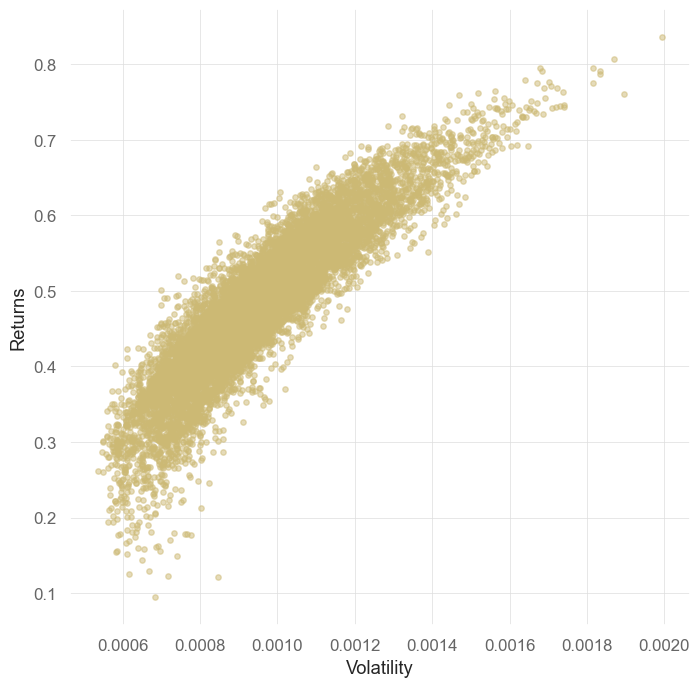

In [149]:
temp.plot.scatter(
    x="Volatility",
    y="Returns",
    marker="o",
    color="y",
    s=15,
    alpha=0.5,
    grid=True,
    figsize=[8, 8],
)

In [150]:
min_vol = temp.iloc[temp["Volatility"].idxmin()]

# risk factor = 0.01
rf = 0.24
optimal_risky_port = temp.iloc[((temp["Returns"] - rf) / temp["Volatility"]).idxmax()]

best_weights = rand_weight_list_p1[((temp["Returns"] - rf) / temp["Volatility"]).idxmax()]

In [179]:
best_min_vol_weights = rand_weight_list_p1[temp["Volatility"].idxmin()]

یافتن نقاط بهینه برای بهترین ریسک و بهترین بازدهی

C:\Users\Win\AppData\Local\Temp\ipykernel_21140\2073086864.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(min_vol[1], min_vol[0], color="y", marker="*", s=500)
C:\Users\Win\AppData\Local\Temp\ipykernel_21140\2073086864.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(optimal_risky_port[1], optimal_risky_port[0], color="b", marker="*", s=500)


Text(0, 0.5, 'Expected Returns')

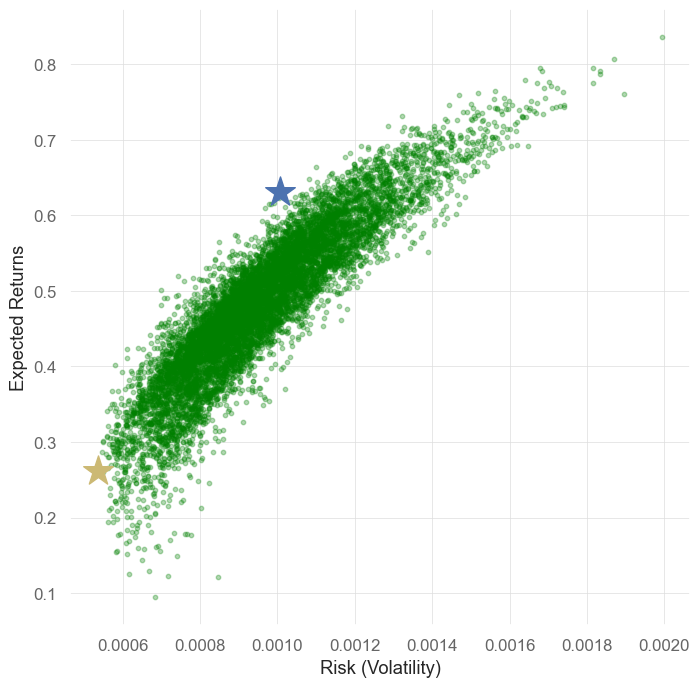

In [151]:
plt.subplots(figsize=(8, 8))
plt.scatter(
    temp["Volatility"], temp["Returns"], marker="o", s=10, alpha=0.3, color="green"
)
plt.scatter(min_vol[1], min_vol[0], color="y", marker="*", s=500)
plt.scatter(optimal_risky_port[1], optimal_risky_port[0], color="b", marker="*", s=500)
plt.xlabel("Risk (Volatility)")
plt.ylabel("Expected Returns")

In [180]:
backtest_rand_weight = generate_random_weight(coins)

random_weight_result = backtest(prices_df, 1000, backtest_rand_weight)
random_weight_result.columns = ["Random"]
best_weight_result = backtest(prices_df, 1000, best_weights)
best_weight_result.columns = ["Best"]
min_vol_weight_result = backtest(prices_df, 1000, best_min_vol_weights)
min_vol_weight_result.columns = ["Min Vol"]

In [181]:
print(f"Best Weights : {best_weights}")
print(f"Random Weights : {backtest_rand_weight}")
print(f"Best Min Vol Weights : {best_min_vol_weights}")

Best Weights : [0.58515789 0.00769692 0.06635353 0.12441172 0.21637995]
Random Weights : [0.04674501 0.22208418 0.27954752 0.20224572 0.24937756]
Best Min Vol Weights : [0.42420819 0.12193667 0.4453848  0.00553112 0.00293922]


رسم نمودار برای وزن‌های بهینه و وزن‌های رندوم

<Axes: xlabel='Date'>

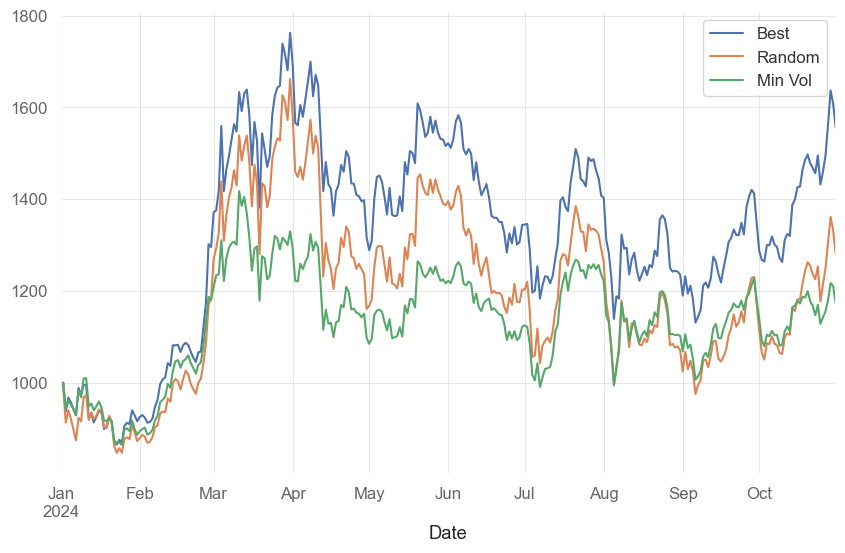

In [182]:
final_result = pd.concat(
    [best_weight_result, random_weight_result, min_vol_weight_result], axis=1
)
final_result.plot()

همانطور که مشاهده می‌شود، وزن‌های بهینه، سودآوری بیشتری دارند.

In [183]:
text = f"""Sharpe Ratio
\tRandom Weight Result: {get_portfolio_sharpe_ratio(prices_df, backtest_rand_weight)}
\tBest Weight Result : {get_portfolio_sharpe_ratio(prices_df, best_weights)}
\tMin Vol Result : {get_portfolio_sharpe_ratio(prices_df, best_min_vol_weights)}
Expected Return
\tRandom Weight Result : {get_portfolio_return(prices_df, backtest_rand_weight)}
\tBest Weight Result : {get_portfolio_return(prices_df, best_weights)}
\tMin Vol Result : {get_portfolio_return(prices_df, best_min_vol_weights)}
Risk(Variance)
\tRandom Weight Result : {get_portfolio_risk(prices_df, backtest_rand_weight)}
\tBest Weight Result : {get_portfolio_risk(prices_df, best_weights)}
\tMin Vol Result : {get_portfolio_risk(prices_df, best_min_vol_weights)}
Maximum Drawdown
\tRandom Weight Result : {qs.stats.max_drawdown(pd.DataFrame(np.dot(prices_df, backtest_rand_weight), index=prices_df.index))[0]}
\tBest Weight Result : {qs.stats.max_drawdown(pd.DataFrame(np.dot(prices_df, best_weights), index=prices_df.index))[0]}
\tMin Vol Result : {qs.stats.max_drawdown(pd.DataFrame(np.dot(prices_df, best_min_vol_weights), index=prices_df.index))[0]}
"""

نتایج وزن‌های بهینه برای حالت رندوم، بهترین ریسک و همچنین برای کمترین ریسک

In [184]:
print(text)

Sharpe Ratio
	Random Weight Result: 9.460795648235534
	Best Weight Result : 11.885683895038737
	Min Vol Result : 15.994092580182306
Expected Return
	Random Weight Result : 0.5216392775993864
	Best Weight Result : 0.7148665149960276
	Min Vol Result : 0.28004905332010344
Risk(Variance)
	Random Weight Result : 0.000938361468122881
	Best Weight Result : 0.0010069298417896932
	Min Vol Result : 0.0005371840812891836
Maximum Drawdown
	Random Weight Result : -0.2991776116860866
	Best Weight Result : -0.26194059413839366
	Min Vol Result : -0.26465995390599206



# Section 2

In [171]:
start = datetime(2024, 11, 2)
end = datetime(2024, 12, 2)

price_dict2 = {}
for coin in coins:
    data = yf.Ticker(coin).history(interval="1d", start=start, end=end)
    price_dict2[coin] = data.Close

prices2_df = pd.DataFrame(price_dict2)

In [185]:
best_weight_return = backtest(prices2_df, 1000, best_weights)
best_weight_return.columns = ["Best"]
rand_weight = generate_random_weight(coins)
random_weight_return = backtest(prices2_df, 1000, rand_weight)
random_weight_return.columns = ["Random"]
min_vol_result = backtest(prices2_df, 1000, best_min_vol_weights)
min_vol_result.columns = ["Min Vol"]

In [186]:
print(f"Best Weights : {best_weights}")
print(f"Random Weights : {rand_weight}")
print(f"Min Vol Weights : {best_min_vol_weights}")

Best Weights : [0.58515789 0.00769692 0.06635353 0.12441172 0.21637995]
Random Weights : [0.15686393 0.25446602 0.15490219 0.26469033 0.16907753]
Min Vol Weights : [0.42420819 0.12193667 0.4453848  0.00553112 0.00293922]


رسم نمودار برای وزن‌های رندوم و وزن‌های یافت شده در قسمت قبل

<Axes: xlabel='Date'>

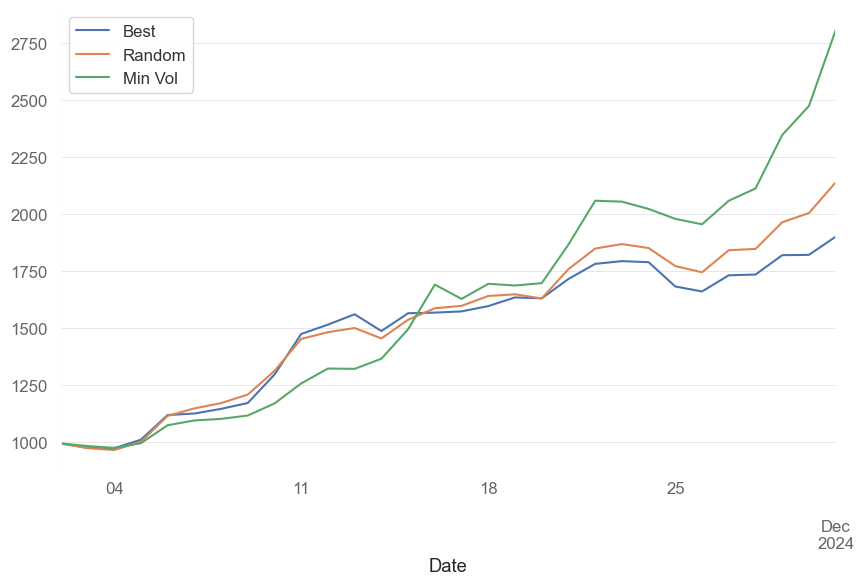

In [187]:
part2_final = pd.concat([best_weight_return, random_weight_return,min_vol_result], axis=1)
part2_final.plot()

In [190]:
text = f"""Sharpe Ratio
\tRandom Weight Result: {get_portfolio_sharpe_ratio(prices2_df, rand_weight)}
\tBest Weight Result : {get_portfolio_sharpe_ratio(prices2_df, best_weights)}
\tMin Vol Result : {get_portfolio_sharpe_ratio(prices2_df, best_min_vol_weights)}
Expected Return
\tRandom Weight Result : {get_portfolio_return(prices2_df, rand_weight)}
\tBest Weight Result : {get_portfolio_return(prices2_df, best_weights)}
\tMin Vol Result : {get_portfolio_return(prices2_df, best_min_vol_weights)}
Risk(Variance)
\tRandom Weight Result : {get_portfolio_risk(prices2_df, rand_weight)}
\tBest Weight Result : {get_portfolio_risk(prices2_df, best_weights)}
\tMin Vol Result : {get_portfolio_risk(prices2_df, best_min_vol_weights)}
Maximum Drawdown
\tRandom Weight Result : {qs.stats.max_drawdown(pd.DataFrame(np.dot(prices2_df, rand_weight), index=prices2_df.index))[0]}
\tBest Weight Result : {qs.stats.max_drawdown(pd.DataFrame(np.dot(prices2_df, best_weights), index=prices2_df.index))[0]}
\tMin Vol Result : {qs.stats.max_drawdown(pd.DataFrame(np.dot(prices2_df, best_min_vol_weights), index=prices2_df.index))[0]}
"""

نتایج برای یک ماه آخر

In [191]:
print(text)

Sharpe Ratio
	Random Weight Result: 413.29392323886736
	Best Weight Result : 436.8266562442273
	Min Vol Result : 393.21191172234614
Expected Return
	Random Weight Result : 158441.42322223
	Best Weight Result : 69900.91555249685
	Min Vol Result : 448722.135519522
Risk(Variance)
	Random Weight Result : 0.0025708864036005324
	Best Weight Result : 0.002175259255645109
	Min Vol Result : 0.002711145073030915
Maximum Drawdown
	Random Weight Result : -0.06737873001713868
	Best Weight Result : -0.07081853404490779
	Min Vol Result : -0.07017001509491427

